# Zadanie Pipline

Wybierz zbiór danych z tych, które wykorzystywane były w module o regresji lub klasyfikacji. Dla któregoś z tych zbiorów stwórz Pipeline, w którym zawrzesz proces przygotowania danych i naucz nowy model, porównując go z tymi stworzonymi w tamtych modułach.

## Import bibliotek i danych

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.decomposition import PCA

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import classification_report, confusion_matrix, f1_score, roc_auc_score, accuracy_score, precision_score, recall_score

dataset = pd.read_csv('penguins.csv')

Lista modeli jakie zostaną użyte. Dodałem 3 element krotki zawierajacy parametry wykożystywane przez GridSearchCV.

In [3]:
modele = [
    ("Logistic Regression", LogisticRegression(max_iter=10000), {'Logistic Regression__C': [0.1, 1.0, 10.0], 'preprocessor__numeric_preprocessing__polynomial_features__degree': [1, 2, 3]}),
    ("Decision Tree",       DecisionTreeClassifier(), {'Decision Tree__max_depth': [3, 5, 10, None],'Decision Tree__min_samples_split': [2, 5, 10], 'preprocessor__numeric_preprocessing__polynomial_features__degree': [1, 2, 3]}),
    ("Random Forest",       RandomForestClassifier(),  {'Random Forest__n_estimators': [50, 100],'Random Forest__max_depth': [3, 5, 20, None], 'preprocessor__numeric_preprocessing__polynomial_features__degree': [1, 2, 3]}),
    ("AdaBoost",            AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=1), n_estimators=50), {'AdaBoost__n_estimators': [50, 100, 200],'AdaBoost__learning_rate': [0.1, 0.5, 1.0], 'preprocessor__numeric_preprocessing__polynomial_features__degree': [1, 2, 3]}),
    ("SVM",                 SVC(probability=True),  {'SVM__C': [0.1, 1.0, 10.0], 'SVM__kernel': ['linear', 'rbf'], 'SVM__gamma': ['scale', 'auto'], 'preprocessor__numeric_preprocessing__polynomial_features__degree': [1, 2, 3]}),
    ("KNN",                 KNeighborsClassifier(), {'KNN__n_neighbors': [3, 5, 7, 9], 'KNN__weights': ['uniform', 'distance'], 'KNN__p': [1, 2], 'preprocessor__numeric_preprocessing__polynomial_features__degree': [1, 2, 3]})
]

Funkcja wyliczająca metryki dla każdego modelu i zapisująca je do DF

In [4]:
metrics_dataframe = pd.DataFrame(columns=['Model', 'F1_score', 'AUC'])
models = []
models_names = []
predictions_proba_list = []

def calculate_metrics(model, name, X_checked, y_checked):
    # Predykcje
    predictions = model.predict(X_checked)
    predictions_proba = model.predict_proba(X_checked)
    
    # Zapisujemy model i wyniki
    models.append(model)
    models_names.append(name)
    predictions_proba_list.append(predictions_proba)
    
    # ==================== METRYKI ====================
    # Zapis metryk
    f1_metric = f1_score(y_checked, predictions, average='macro')
    auc_metric = roc_auc_score(y_checked, predictions_proba, multi_class='ovr')
    acc_metric = accuracy_score(y_checked, predictions)
    prec_metric = precision_score(y_checked, predictions, average='macro')
    rec_metric = recall_score(y_checked, predictions, average='macro')
    
    global metrics_dataframe
    new_row = pd.DataFrame([{
        'Model': name, 
        'Accuracy': acc_metric,
        'Precision': prec_metric,
        'Recall': rec_metric,
        'F1_score': f1_metric, 
        'AUC': auc_metric
    }])
    metrics_dataframe = pd.concat([metrics_dataframe, new_row], ignore_index=True)
    
    #print(metrics_dataframe.round(4))
    return metrics_dataframe
    



In [5]:
features = ['CulmenLength','CulmenDepth','FlipperLength','BodyMass']
target = 'Species'

In [6]:
dataset = dataset.dropna(how='all')
dataset = dataset.dropna(subset=['Species'])

podział na zbiory testowe i treningowe

In [7]:

X, y = dataset[features], dataset[target]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42, stratify=y)

Tworzenie piplinu

In [8]:
num_preparation = Pipeline(steps=[
    ('fill_missings', SimpleImputer(strategy='mean')),
    ('polynomial_features', PolynomialFeatures(degree=3)),
    ('scaler_1', StandardScaler()),
    ('pca', PCA(n_components=0.95)),
    ('scaler_2', StandardScaler())
])

data_preparation = ColumnTransformer(transformers=[('numeric_preprocessing', num_preparation, features),])

pętla do uczenia wszystkich modeli z listy z wykorzystaniem najlepszych hiper parametrów ustalonych przy użyciu GridSearchCV 

In [9]:
for nazwa_modelu, obiekt_modelu, parametry in modele:
    
    aktualny_pipeline = Pipeline(steps=[('preprocessor', data_preparation), (nazwa_modelu, obiekt_modelu)])
    
    grid = GridSearchCV(aktualny_pipeline, parametry, cv=5, scoring='f1_macro', n_jobs=-1)
    print(f"\n--- Szukam najlepszych parametrów dla: {nazwa_modelu} ---")
    grid.fit(X_train, y_train)
    najlepszy_pipeline = grid.best_estimator_
    print(f"Wybrane hiperparametry: {grid.best_params_}")

    calculate_metrics(najlepszy_pipeline, nazwa_modelu, X_test, y_test)


--- Szukam najlepszych parametrów dla: Logistic Regression ---
Wybrane hiperparametry: {'Logistic Regression__C': 1.0, 'preprocessor__numeric_preprocessing__polynomial_features__degree': 1}

--- Szukam najlepszych parametrów dla: Decision Tree ---
Wybrane hiperparametry: {'Decision Tree__max_depth': 5, 'Decision Tree__min_samples_split': 2, 'preprocessor__numeric_preprocessing__polynomial_features__degree': 2}

--- Szukam najlepszych parametrów dla: Random Forest ---
Wybrane hiperparametry: {'Random Forest__max_depth': 20, 'Random Forest__n_estimators': 100, 'preprocessor__numeric_preprocessing__polynomial_features__degree': 1}

--- Szukam najlepszych parametrów dla: AdaBoost ---
Wybrane hiperparametry: {'AdaBoost__learning_rate': 0.5, 'AdaBoost__n_estimators': 50, 'preprocessor__numeric_preprocessing__polynomial_features__degree': 2}

--- Szukam najlepszych parametrów dla: SVM ---
Wybrane hiperparametry: {'SVM__C': 10.0, 'SVM__gamma': 'scale', 'SVM__kernel': 'rbf', 'preprocessor__num

In [10]:
display(metrics_dataframe)

,Model,F1_score,AUC,Accuracy,Precision,Recall
0,Logistic Regression,0.988286,1.0,0.990385,0.992908,0.984127
1,Decision Tree,0.95503,0.966013,0.961538,0.958543,0.951999
2,Random Forest,0.975305,0.999176,0.980769,0.984136,0.968254
3,AdaBoost,0.950648,0.977572,0.961538,0.958116,0.945135
4,SVM,0.988286,0.999684,0.990385,0.992908,0.984127
5,KNN,0.988286,1.0,0.990385,0.992908,0.984127


Wykres przedtswaiajcy dokładność modeli.

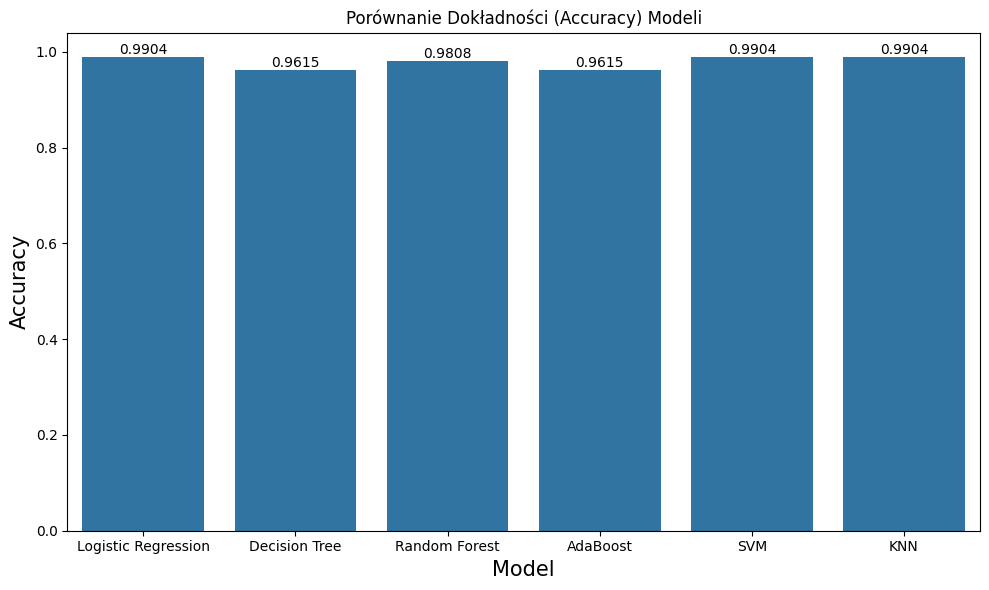

In [11]:
plt.figure(figsize=(10, 6))
ax = sns.barplot(data=metrics_dataframe, x='Model', y='Accuracy')
for container in ax.containers:
    ax.bar_label(container, fmt='%.4f')

plt.title('Porównanie Dokładności (Accuracy) Modeli')
plt.ylabel('Accuracy', fontsize=15)
plt.xlabel('Model', fontsize=15)
plt.tight_layout()
plt.show()

Względem poprzedniego zadania widać poprawę random forest oraz AdaBoost jednak dokładność Decision Tree nieznacznie spadła. Spowodowane jest prawdopodobnie tym że wcześniej uzyłem stałego hiperparametru "PolynomialFeatures(degree=3)" a w tym przypadku GridSearchCV wolał nie ryzykował przeuczenia modelu i wybrał degree=2. 